In [136]:
import pylab as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.io import savemat
from matplotlib.gridspec import GridSpec
from math import radians,sin,asin,sqrt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FixedLocator


In [322]:
params = {'font.size': 14,
          'figure.figsize': (30, 20),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [332]:
def map_gol_cal(fig,ax,limites=None):
    """
    Mercator map of the Gulf of California
    limites = [south, north, west, east] (lon negative)
    """
    if limites is None or len(limites) == 0:
        limites = [22, 32, -116, -105]

    lat_s, lat_n, lon_w, lon_e = limites

    ax.set_extent([lon_w, lon_e, lat_s, lat_n],
                  crs=ccrs.PlateCarree())

    # Coast & land
    ax.add_feature(cfeature.LAND, facecolor='0.7')
    ax.add_feature(cfeature.COASTLINE, linewidth=1)

    # ---- GRIDLINES: LABELS ONLY, NO VISIBLE LINES ----
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0,        # <-- hides grid lines
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False

    gl.xformatter = LongitudeFormatter(degree_symbol='°')
    gl.yformatter = LatitudeFormatter(degree_symbol='°')
    return ax

def plot_square(x_start, y_start, x_end,y_end,ax):
    """Plots a square by defining its four corners and connecting them with lines."""
    x_coords = [x_start, x_end, x_end, x_start,x_start]
    y_coords = [y_start, y_start, y_end, y_end, y_start]
    
    ax.plot(x_coords, y_coords, color='red', linewidth=1,linestyle='solid',transform=ccrs.PlateCarree())
    

In [333]:
dz = 1
arch_out = "../batimetria/bat_surfer_grd.mat"
op_out = True

latmin =28 + 12/60
latmax =30
lonmin =111.8
lonmax = 114.0

limites = [latmin, latmax, -lonmax, -lonmin]

latmin1 =28.38 #28 + 12/60
latmax1 =28.48 #30
lonmin1 = 112.5#111.8
lonmax1 = 112.9#114.0

limites1 = [latmin1, latmax1, -lonmax1, -lonmin1]

latmin2 =29.25 #28 + 12/60
latmax2 =29.5 #30
lonmin2 = 113.5#111.8
lonmax2 = 113.75#114.0

limites2 = [latmin2, latmax2, -lonmax2, -lonmin2]

latmin3 =28.55 #28 + 12/60
latmax3 =28.7 #30
lonmin3 = 112.6#111.8
lonmax3 = 112.8#114.0

limites3 = [latmin3, latmax3, -lonmax3, -lonmin3]

latmin4 =29.5 #28 + 12/60
latmax4 =29.825 #30
lonmin4 = 113.45#111.8
lonmax4 = 113.65#114.0

limites4 = [latmin4, latmax4, -lonmax4, -lonmin4]

nx = 500   # longitude dimension
ny = 430   # latitude dimension

tray_bat = "../batimetria/alby0203_surf_grd.dat"

data = np.loadtxt(tray_bat)

lon_b = data[:, 0]
lat_b = data[:, 1]
bat   = data[:, 2]


lat_b = lat_b.reshape(nx, ny, order="F").T
lon_b = lon_b.reshape(nx, ny, order="F").T
bat   = bat.reshape(nx, ny, order="F").T


mask = lat_b <= latmax
iy, ix = np.where(mask)

iy1, iy2 = iy.min(), iy.max()
ix1, ix2 = ix.min(), ix.max()

lat_b = lat_b[iy1:iy2 + 1, ix1:ix2 + 1]
lon_b = lon_b[iy1:iy2 + 1, ix1:ix2 + 1]
bat   = bat[iy1:iy2 + 1, ix1:ix2 + 1]

ny2, nx2 = lat_b.shape


In [334]:
maskin = np.logical_and(np.logical_and(lat_b <= latmax,lat_b>= latmin),np.logical_and(lon_b <= lonmax,lon_b>= lonmin))
maskin1 = np.logical_and(np.logical_and(lat_b <= latmax1,lat_b>= latmin1),np.logical_and(lon_b <= lonmax1,lon_b>= lonmin1))
maskin2 = np.logical_and(np.logical_and(lat_b <= latmax2,lat_b>= latmin2),np.logical_and(lon_b <= lonmax2,lon_b>= lonmin2))
maskin3 = np.logical_and(np.logical_and(lat_b <= latmax3,lat_b>= latmin3),np.logical_and(lon_b <= lonmax3,lon_b>= lonmin3))
maskin4 = np.logical_and(np.logical_and(lat_b <= latmax4,lat_b>= latmin4),np.logical_and(lon_b <= lonmax4,lon_b>= lonmin4))

In [335]:
def haversine(lon1, lat1, lon2, lat2):

# ######   Calculate the great circle distance in kilometers between two points on the earth (specified in decimal degrees)
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c * r

In [336]:

lon_pt1, lat_pt1 = -112.612, 28.429
lon_pt11, lat_pt11 = -112.628, 28.413

lon_pt2, lat_pt2 = -113.6, 29.4
lon_pt12, lat_pt12 = -113.665, 29.315

lon_pt3, lat_pt3 = -112.725, 28.6
lon_pt13, lat_pt13 = -112.68, 28.65

lon_pt4, lat_pt4 = -113.58, 29.63
lon_pt14, lat_pt14 = -113.56, 29.81

lon=[-112.5,lon_pt1,lon_pt11,lon_pt12,lon_pt2,-113.75,lon_pt4,lon_pt14,-113,lon_pt3,lon_pt13]
lat=[28.35,lat_pt1,lat_pt11,lat_pt12,lat_pt2,29.51,lat_pt4,lat_pt14,29.3,lat_pt3,lat_pt13]

In [337]:
dist_array = np.zeros(len(lon)-1)
p=0
for jj in range(len(lon)-1):
    lat1 = lat[jj+1]
    lon1 = lon[jj+1]
    lat2 = lat[jj]
    lon2 = lon[jj]
    p=p+1
    dist_array[p-1]=  haversine(lat1, lon1, lat2, lon2)
    
dist_cummul = np.cumsum(dist_array)

In [338]:
dist_cummul

array([ 12.90162359,  14.80779864, 136.66753389, 144.82807844,
       162.2154228 , 181.86265467, 190.16929899, 256.34873544,
       299.35493998, 304.79938923])

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_30915/1194018868.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/SVB/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  

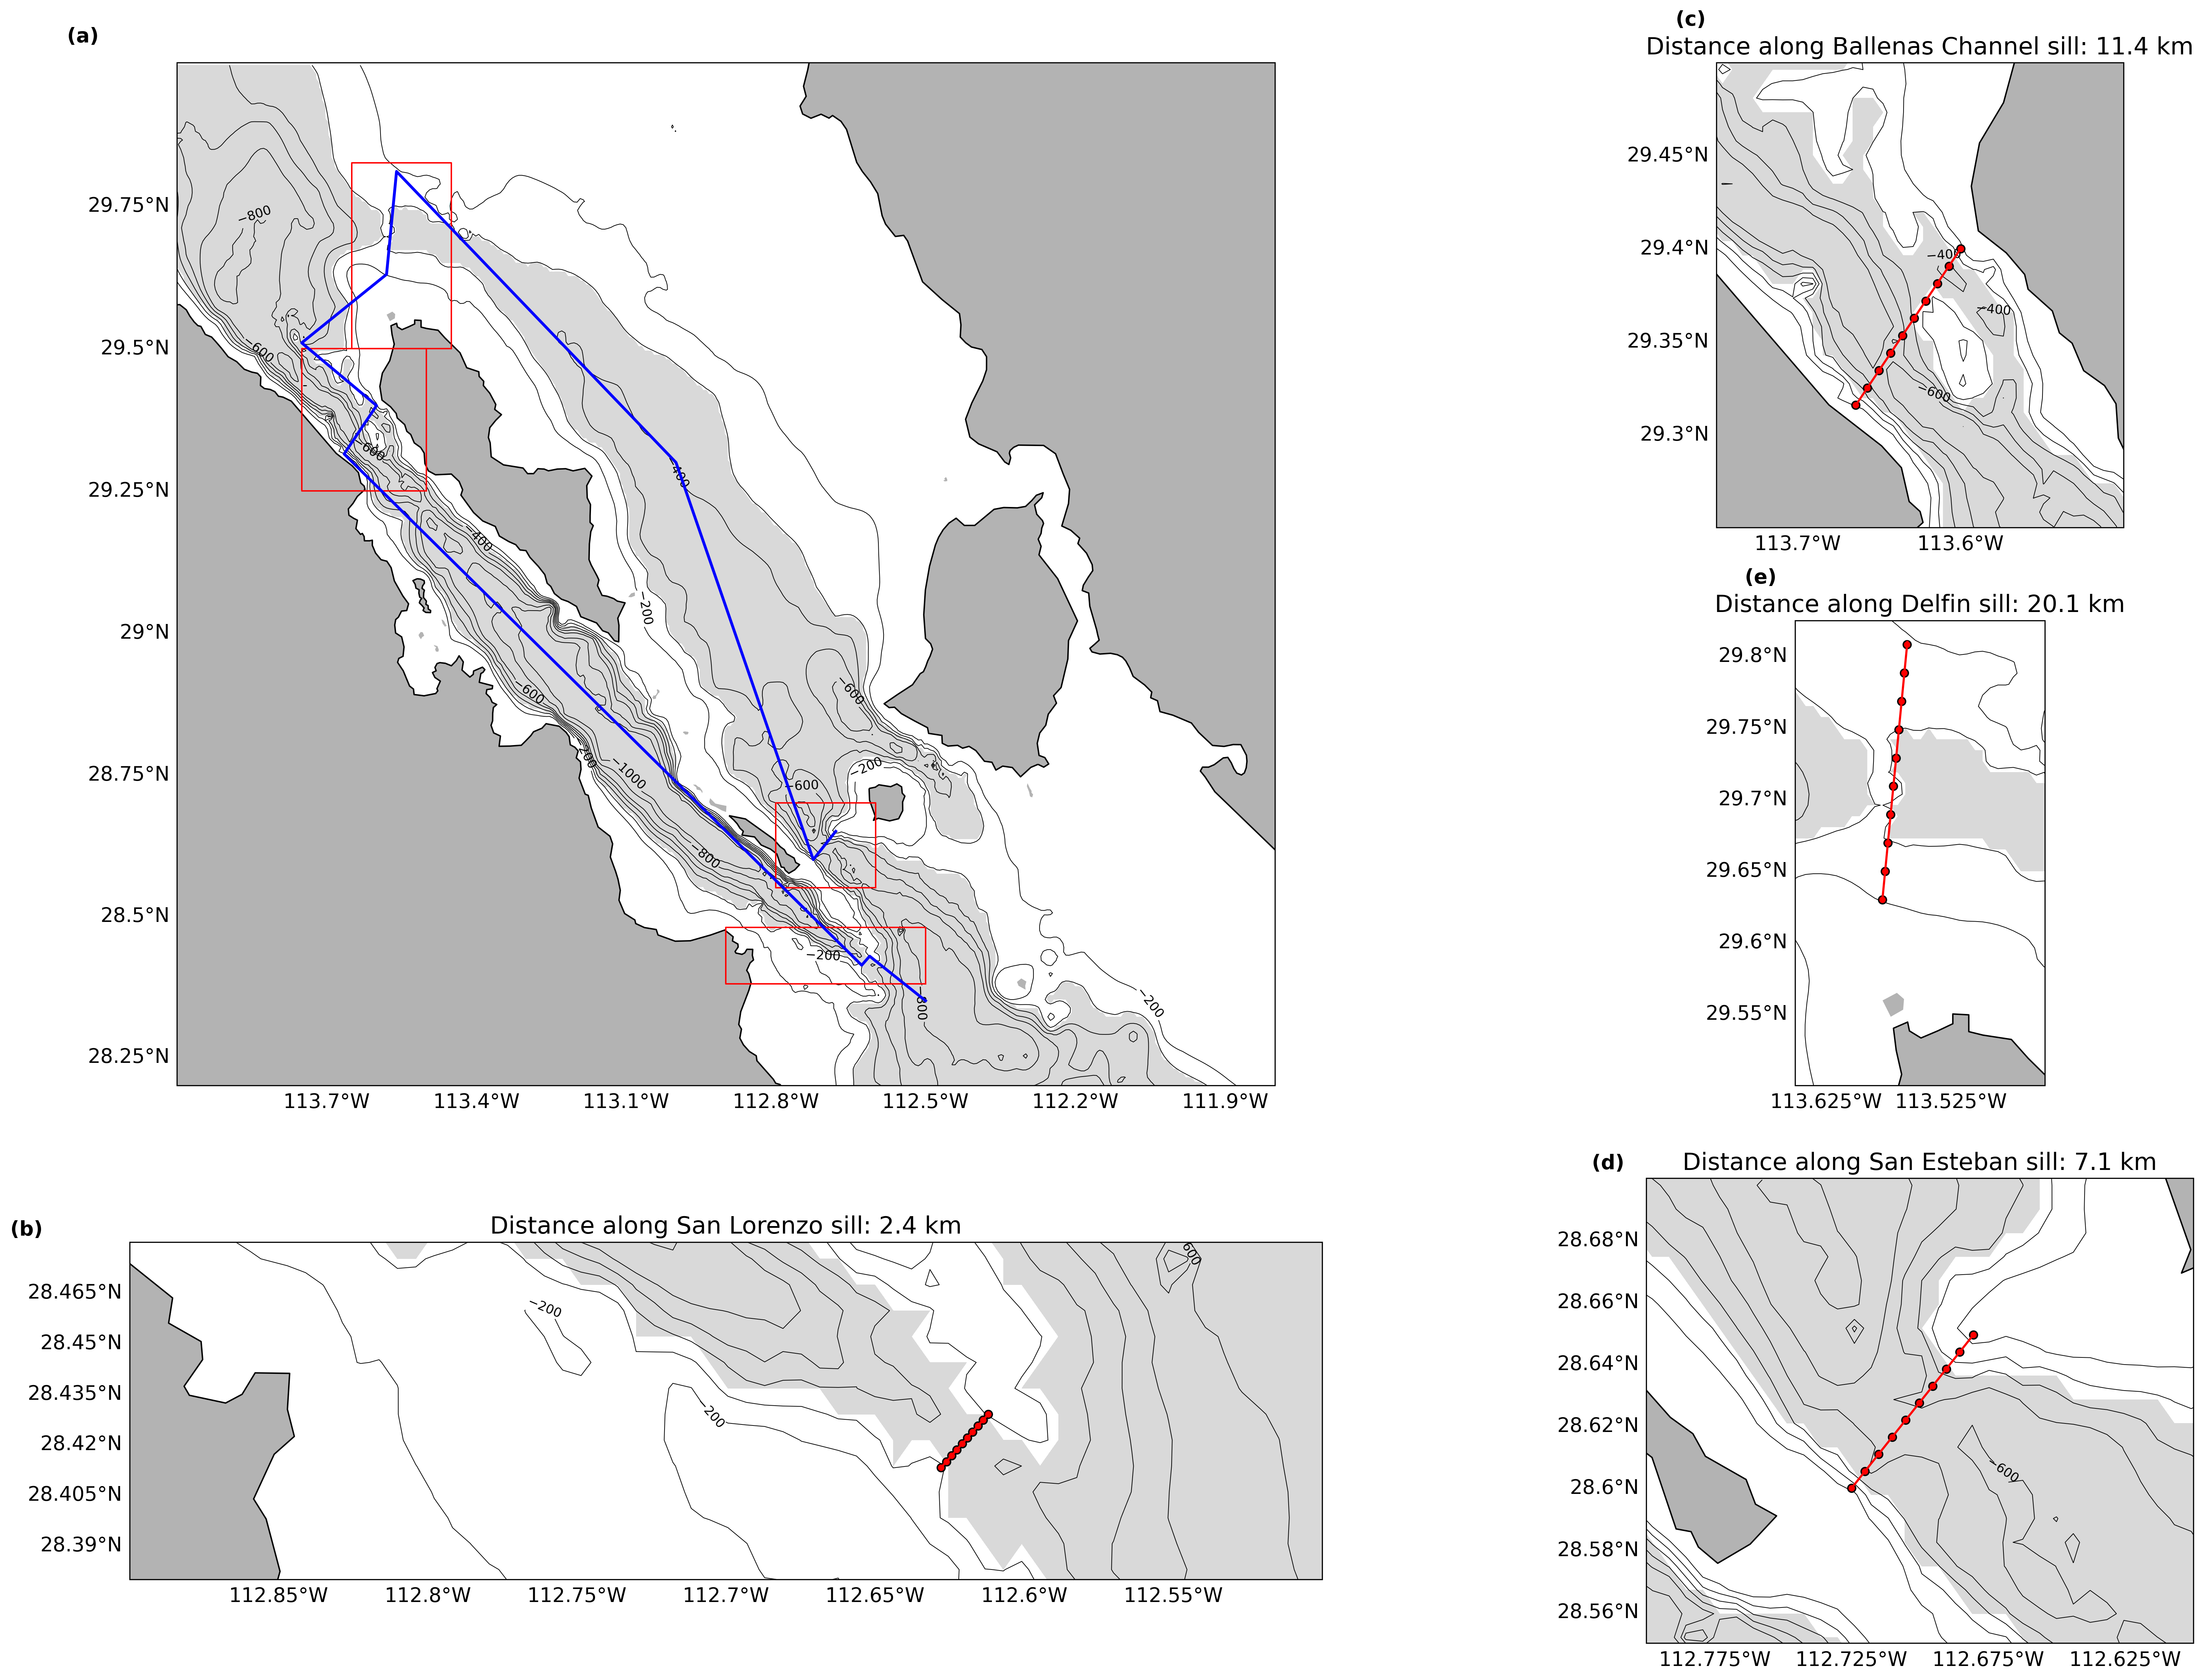

In [342]:

mpl.rcParams['contour.negative_linestyle'] = 'solid'

fig = plt.figure()
gs = GridSpec(nrows=3, ncols=2,wspace=0.001)
proj = ccrs.Mercator()
ax = fig.add_subplot(gs[0:2, 0],projection=proj)
ax=map_gol_cal(fig,ax,limites)

ax.text(-0.1, 1.02, '(a)', fontweight='bold', color='k', 
        transform=ax.transAxes)
levels = np.sort([-200, -400, -600, -800, -1000])
levels2 = np.sort([-300, -500])

bat_deep = np.ma.masked_where(bat > -300, bat)

ax.contourf(
    lon_b,
    lat_b,
    np.ma.masked_array(bat_deep,mask=maskin),
    levels=[bat.min(), -300],
    colors=['0.85'],   # light gray
    transform=ccrs.PlateCarree(),
    zorder=0
)

cs = ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin),
    levels=levels,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree(),
    zorder=1
)

ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin),
    levels=levels2,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree(),
    zorder=1
)

plot_square(-lonmin1, latmin1, -lonmax1,latmax1,ax)
plot_square(-lonmin2, latmin2, -lonmax2,latmax2,ax)
plot_square(-lonmin3, latmin3, -lonmax3,latmax3,ax)
plot_square(-lonmin4, latmin4, -lonmax4,latmax4,ax)

ax.plot(
    lon,
    lat,
    color='blue',
    transform=ccrs.PlateCarree(),
    linewidth=2,
    zorder=10          # make sure it's on top of contours and filled areas
)
ax.clabel(cs, inline=True, fontsize=9)

ax = fig.add_subplot(gs[2, 0],projection=proj)
ax=map_gol_cal(fig,ax,limites1)
ax.text(-0.1, 1.02, '(b)', fontweight='bold', color='k', 
        transform=ax.transAxes)
levels = np.sort([-200, -400, -600, -800, -1000])
levels2 = np.sort([-300, -500])

bat_deep = np.ma.masked_where(bat > -300, bat)

ax.contourf(
    lon_b,
    lat_b,
    np.ma.masked_array(bat_deep,mask=maskin1),
    levels=[bat.min(), -300],
    colors=['0.85'],   # light gray
    transform=ccrs.PlateCarree()
)

cs = ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin1),
    levels=levels,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin1),
    levels=levels2,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.clabel(cs, inline=True, fontsize=9)

lon_pt, lat_pt = -112.612, 28.429
lon_pt1, lat_pt1 = -112.628, 28.413

ax.scatter(
    np.arange(lon_pt,lon_pt1+(lon_pt1-lon_pt)/10,((lon_pt1+(lon_pt1-lon_pt)/10)-lon_pt)/10),
    np.arange(lat_pt,lat_pt1+(lat_pt1-lat_pt)/10,(lat_pt1+(lat_pt1-lat_pt)/10-lat_pt)/10),
    s=30,              # marker size (larger for visibility)
    color='red',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

ax.plot(
    [lon_pt1,lon_pt],
    [lat_pt1,lat_pt],
    color='red',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

distSL=haversine(lon_pt1, lat_pt1, lon_pt, lat_pt)
ax.set_title(f'Distance along San Lorenzo sill: {distSL:.1f} km')

ax = fig.add_subplot(gs[0, 1],projection=proj)
ax=map_gol_cal(fig,ax,limites2)
ax.text(-0.1, 1.08, '(c)', fontweight='bold', color='k', 
        transform=ax.transAxes)

levels = np.sort([-200, -400, -600, -800, -1000])
levels2 = np.sort([-300, -500])

bat_deep = np.ma.masked_where(bat > -300, bat)

ax.contourf(
    lon_b,
    lat_b,
    np.ma.masked_array(bat_deep,mask=maskin2),
    levels=[bat.min(), -300],
    colors=['0.85'],   # light gray
    transform=ccrs.PlateCarree()
)

cs = ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin2),
    levels=levels,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin2),
    levels=levels2,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.clabel(cs, inline=True, fontsize=9)


lon_pt, lat_pt = -113.6, 29.4
lon_pt1, lat_pt1 = -113.665, 29.315

ax.scatter(
    np.arange(lon_pt,lon_pt1+(lon_pt1-lon_pt)/10,((lon_pt1+(lon_pt1-lon_pt)/10)-lon_pt)/10),
    np.arange(lat_pt,lat_pt1+(lat_pt1-lat_pt)/10,(lat_pt1+(lat_pt1-lat_pt)/10-lat_pt)/10),
    s=30,              # marker size (larger for visibility)
    color='red',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

ax.plot(
    [lon_pt1,lon_pt],
    [lat_pt1,lat_pt],
    color='red',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

distBC=haversine(lon_pt1, lat_pt1, lon_pt, lat_pt)
ax.set_title(f'Distance along Ballenas Channel sill: {distBC:.1f} km')

ax = fig.add_subplot(gs[2, 1],projection=proj)
ax=map_gol_cal(fig,ax,limites3)
ax.text(-0.1, 1.02, '(d)', fontweight='bold', color='k', 
        transform=ax.transAxes)
levels = np.sort([-200, -400, -600, -800, -1000])
levels2 = np.sort([-300, -500])

bat_deep = np.ma.masked_where(bat > -300, bat)

ax.contourf(
    lon_b,
    lat_b,
    np.ma.masked_array(bat_deep,mask=maskin3),
    levels=[bat.min(), -300],
    colors=['0.85'],   # light gray
    transform=ccrs.PlateCarree()
)

cs = ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin3),
    levels=levels,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin3),
    levels=levels2,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.clabel(cs, inline=True, fontsize=9)


lon_pt, lat_pt = -112.725, 28.6
lon_pt1, lat_pt1 = -112.68, 28.65

ax.scatter(
    np.arange(lon_pt,lon_pt1+(lon_pt1-lon_pt)/10,((lon_pt1+(lon_pt1-lon_pt)/10)-lon_pt)/10),
    np.arange(lat_pt,lat_pt1+(lat_pt1-lat_pt)/10,(lat_pt1+(lat_pt1-lat_pt)/10-lat_pt)/10),
    s=30,              # marker size (larger for visibility)
    color='red',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)


ax.plot(
    [lon_pt1,lon_pt],
    [lat_pt1,lat_pt],
    color='red',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

distSE=haversine(lon_pt1, lat_pt1, lon_pt, lat_pt)
ax.set_title(f'Distance along San Esteban sill: {distSE:.1f} km')

ax = fig.add_subplot(gs[1, 1],projection=proj)
ax=map_gol_cal(fig,ax,limites4)
ax.text(-0.2, 1.08, '(e)', fontweight='bold', color='k', 
        transform=ax.transAxes)
levels = np.sort([-200, -400, -600, -800, -1000])
levels2 = np.sort([-300, -500])

bat_deep = np.ma.masked_where(bat > -300, bat)

ax.contourf(
    lon_b,
    lat_b,
    np.ma.masked_array(bat_deep,mask=maskin4),
    levels=[bat.min(), -300],
    colors=['0.85'],   # light gray
    transform=ccrs.PlateCarree()
)

cs = ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin4),
    levels=levels,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin4),
    levels=levels2,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree()
)

ax.clabel(cs, inline=True, fontsize=9)


lon_pt, lat_pt = -113.58, 29.63
lon_pt1, lat_pt1 = -113.56, 29.81

ax.scatter(
    np.arange(lon_pt,lon_pt1+(lon_pt1-lon_pt)/10,((lon_pt1+(lon_pt1-lon_pt)/10)-lon_pt)/10),
    np.arange(lat_pt,lat_pt1+(lat_pt1-lat_pt)/10,(lat_pt1+(lat_pt1-lat_pt)/10-lat_pt)/10),
    s=30,              # marker size (larger for visibility)
    color='red',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)


ax.plot(
    [lon_pt1,lon_pt],
    [lat_pt1,lat_pt],
    color='red',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

distDEL=haversine(lon_pt1, lat_pt1, lon_pt, lat_pt)
ax.set_title(f'Distance along Delfin sill: {distDEL:.1f} km')
fig.tight_layout()

plt.savefig('../batimetria/mapa.png')

In [340]:
distSL

2.3692859050858965

In [341]:
distBC

11.35850068734455

In [223]:
distDEL

20.108054574923774

In [224]:
distSE

7.085339021178341

In [273]:

lon_pt1, lat_pt1 = -112.612, 28.429
lon_pt11, lat_pt11 = -112.628, 28.413

lon_pt2, lat_pt2 = -113.6, 29.4
lon_pt12, lat_pt12 = -113.665, 29.315

lon_pt3, lat_pt3 = -112.725, 28.6
lon_pt13, lat_pt13 = -112.68, 28.65

lon_pt4, lat_pt4 = -113.58, 29.63
lon_pt14, lat_pt14 = -113.56, 29.81

lon=[-112,lon_pt1,lon_pt11,lon_pt12,lon_pt2,-113.75,lon_pt3,lon_pt13,113,lon_pt4,lon_pt14]
lat=[28.35,lat_pt1,lat_pt11,lat_pt12,lat_pt2,29.7,lat_pt3,lat_pt13,29.3,lat_pt4,lat_pt14]

In [ ]:
# -----------------------------
# Save output (.mat)
# -----------------------------
if op_out:
    savemat(
        arch_out,
        {
            "lon_b": lon_b,
            "lat_b": lat_b,
            "bat": bat
        }
    )
